# Student Dropout Prediction — Model Training and Feature Selection

## Import Library

In [70]:
# Core libraries
from pathlib import Path
import json

import pandas as pd
import numpy as np

In [71]:
# Visualization library
import matplotlib.pyplot as plt

In [72]:
# Data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [73]:
# Models and pipeline
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [74]:
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [75]:
# Feature selection and model saving
from sklearn.inspection import permutation_importance
from sklearn.base import clone

import joblib

## Get Data

In [76]:
# Define project and data paths
current_path = Path.cwd()

if (current_path / "data" / "processed" / "processed.csv").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed.csv"

print("Project root:", PROJECT_ROOT)
print("Processed data path:", PROCESSED_DATA_PATH)
print("Processed dataset exists:", PROCESSED_DATA_PATH.exists())

Project root: c:\not_default\Projects\student-dropout-prediction-ml
Processed data path: c:\not_default\Projects\student-dropout-prediction-ml\data\processed\processed.csv
Processed dataset exists: True


In [77]:
# Load processed dataset
df = pd.read_csv(PROCESSED_DATA_PATH)

print("Processed dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Processed dataset loaded successfully.
Dataset shape: (3630, 22)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,13,10,6,10,...,0,1,1,0,20,0,10.8,1.4,1.74,1
1,1,6,1,11,1,1,1,3,4,4,...,0,0,1,0,19,0,13.9,-0.3,0.79,0
2,1,1,5,5,1,1,22,27,10,10,...,0,0,1,0,19,0,10.8,1.4,1.74,1
3,1,8,2,15,1,1,23,27,6,4,...,0,1,0,0,20,0,9.4,-0.8,-3.12,0
4,2,12,1,3,0,1,22,28,10,10,...,0,1,0,0,45,0,13.9,-0.3,0.79,0


In [78]:
# Validate processed dataset
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows after feature removal:", df.duplicated().sum())
print("Target unique values:", sorted(df["Target"].unique()))

df["Target"].value_counts().sort_index()

Dataset shape: (3630, 22)
Missing values: 0
Duplicate rows after feature removal: 4
Target unique values: [np.int64(0), np.int64(1)]


Target
0    2209
1    1421
Name: count, dtype: int64

## Split Data

In [79]:
# Separate features and target
X = df.drop(columns=["Target"])
y = df["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (3630, 21)
y shape: (3630,)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP
0,1,8,5,2,1,1,13,10,6,10,...,0,0,1,1,0,20,0,10.8,1.4,1.74
1,1,6,1,11,1,1,1,3,4,4,...,0,0,0,1,0,19,0,13.9,-0.3,0.79
2,1,1,5,5,1,1,22,27,10,10,...,0,0,0,1,0,19,0,10.8,1.4,1.74
3,1,8,2,15,1,1,23,27,6,4,...,0,0,1,0,0,20,0,9.4,-0.8,-3.12
4,2,12,1,3,0,1,22,28,10,10,...,0,0,1,0,0,45,0,13.9,-0.3,0.79


In [80]:
# Define continuous features
continuous_features = [
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

# Keep only existing continuous features
continuous_features = [
    col for col in continuous_features
    if col in X.columns
]

# Define categorical-like features
categorical_features = [
    col for col in X.columns
    if col not in continuous_features
]

print("Continuous features:", len(continuous_features))
print(continuous_features)

print("\nCategorical-like features:", len(categorical_features))
print(categorical_features)

Continuous features: 4
['Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP']

Categorical-like features: 17
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


In [81]:
# Split dataset into train-validation-test sets

# First split: separate final test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: create validation set from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\ny_val distribution:")
print(y_val.value_counts(normalize=True).sort_index())

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).sort_index())

X_train shape: (2323, 21)
X_val shape: (581, 21)
X_test shape: (726, 21)

y_train distribution:
Target
0    0.608265
1    0.391735
Name: proportion, dtype: float64

y_val distribution:
Target
0    0.609294
1    0.390706
Name: proportion, dtype: float64

y_test distribution:
Target
0    0.608815
1    0.391185
Name: proportion, dtype: float64


## Define, Train and Evaluate Model

In [82]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("continuous", StandardScaler(), continuous_features)
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('continuous', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [83]:
# Define baseline and main classification models
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes (Main Model)": GaussianNB()
}

In [84]:
# Train and evaluate baseline models on validation set
evaluation_results = []

trained_models = {}

for model_name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train model using training set
    pipeline.fit(X_train, y_train)
    
    # Predict validation set
    y_pred = pipeline.predict(X_val)
    
    # Predict probability for ROC-AUC
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    
    # Store trained model
    trained_models[model_name] = pipeline
    
    # Store validation evaluation metrics
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_proba)
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.805508,0.803191,0.665198,0.727711,0.847221
1,Naive Bayes (Main Model),0.411360,0.397504,0.982379,0.565990,0.515126


In [85]:
# Sort models by ROC-AUC and F1-Score
evaluation_df = evaluation_df.sort_values(
    by=["ROC-AUC", "F1-Score"],
    ascending=False
).reset_index(drop=True)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.805508,0.803191,0.665198,0.727711,0.847221
1,Naive Bayes (Main Model),0.411360,0.397504,0.982379,0.565990,0.515126


In [86]:
# Show classification report and confusion matrix for each model on validation set
for model_name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_val)
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print("\nClassification Report:")
    print(classification_report(
        y_val,
        y_pred,
        target_names=["Graduate", "Dropout"]
    ))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print()

Logistic Regression (Baseline)

Classification Report:
              precision    recall  f1-score   support

    Graduate       0.81      0.90      0.85       354
     Dropout       0.80      0.67      0.73       227

    accuracy                           0.81       581
   macro avg       0.80      0.78      0.79       581
weighted avg       0.81      0.81      0.80       581

Confusion Matrix:
[[317  37]
 [ 76 151]]

Naive Bayes (Main Model)

Classification Report:
              precision    recall  f1-score   support

    Graduate       0.80      0.05      0.09       354
     Dropout       0.40      0.98      0.57       227

    accuracy                           0.41       581
   macro avg       0.60      0.51      0.33       581
weighted avg       0.64      0.41      0.27       581

Confusion Matrix:
[[ 16 338]
 [  4 223]]



In [87]:
# Select best model based on ROC-AUC
best_model_name = evaluation_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Logistic Regression (Baseline)


In [88]:
# Calculate permutation importance using validation set
perm_importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Store permutation importance result
feature_importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

feature_importance_df

,feature,importance_mean,importance_std
0,Tuition fees up to date,0.076333,0.009203
1,Course,0.059690,0.011076
2,Scholarship holder,0.041072,0.008455
3,Application mode,0.035944,0.004121
4,Gender,0.007885,0.002557
5,Debtor,0.007880,0.002189
6,Mother's qualification,0.004472,0.002153
7,Mother's occupation,0.003584,0.002552
8,Unemployment rate,0.003374,0.001880
9,Age at enrollment,0.002765,0.000696


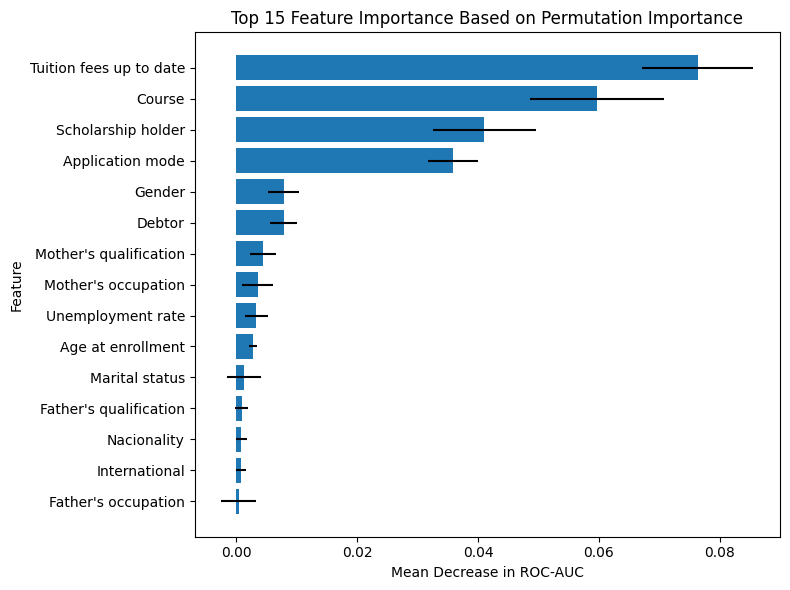

Number of selected MVP features: 10


['Tuition fees up to date',
 'Course',
 'Scholarship holder',
 'Application mode',
 'Gender',
 'Debtor',
 "Mother's qualification",
 "Mother's occupation",
 'Unemployment rate',
 'Age at enrollment']

In [89]:
# Select top features for MVP
MVP_FEATURE_COUNT = 10

mvp_features = (
    feature_importance_df[feature_importance_df["importance_mean"] > 0]
    .head(MVP_FEATURE_COUNT)["feature"]
    .tolist()
)

# Visualize top 15 important features
top_features = feature_importance_df.head(15).sort_values(by="importance_mean")

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.title("Top 15 Feature Importance Based on Permutation Importance")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

print("Number of selected MVP features:", len(mvp_features))
mvp_features

In [90]:
# Create final MVP train-test feature set
X_train_full_mvp = X_train_full[mvp_features].copy()
X_test_mvp = X_test[mvp_features].copy()

# Separate MVP continuous and categorical-like features
mvp_continuous_features = [
    col for col in continuous_features
    if col in mvp_features
]

mvp_categorical_features = [
    col for col in mvp_features
    if col not in mvp_continuous_features
]

print("MVP continuous features:", len(mvp_continuous_features))
print(mvp_continuous_features)

print("\nMVP categorical-like features:", len(mvp_categorical_features))
print(mvp_categorical_features)

print("\nX_train_full_mvp shape:", X_train_full_mvp.shape)
print("X_test_mvp shape:", X_test_mvp.shape)

MVP continuous features: 2
['Age at enrollment', 'Unemployment rate']

MVP categorical-like features: 8
['Tuition fees up to date', 'Course', 'Scholarship holder', 'Application mode', 'Gender', 'Debtor', "Mother's qualification", "Mother's occupation"]

X_train_full_mvp shape: (2904, 10)
X_test_mvp shape: (726, 10)


In [91]:
# Train final full model using train + validation data
final_full_estimator = clone(models[best_model_name])

final_full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_full_estimator)
])

final_full_pipeline.fit(X_train_full, y_train_full)

final_full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('continuous', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [92]:
# Build final MVP preprocessing pipeline
mvp_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), mvp_categorical_features),
        ("continuous", StandardScaler(), mvp_continuous_features)
    ],
    remainder="drop"
)

# Clone best estimator for MVP model
final_mvp_estimator = clone(models[best_model_name])

# Create final MVP pipeline
final_mvp_pipeline = Pipeline(steps=[
    ("preprocessor", mvp_preprocessor),
    ("model", final_mvp_estimator)
])

# Train final MVP model using train + validation data
final_mvp_pipeline.fit(X_train_full_mvp, y_train_full)

final_mvp_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('continuous', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [93]:
# Evaluate final full model on test set
y_pred_full = final_full_pipeline.predict(X_test)
y_proba_full = final_full_pipeline.predict_proba(X_test)[:, 1]

full_test_evaluation = {
    "Model": "Full Model",
    "Accuracy": accuracy_score(y_test, y_pred_full),
    "Precision": precision_score(y_test, y_pred_full),
    "Recall": recall_score(y_test, y_pred_full),
    "F1-Score": f1_score(y_test, y_pred_full),
    "ROC-AUC": roc_auc_score(y_test, y_proba_full)
}

# Evaluate final MVP model on test set
y_pred_mvp = final_mvp_pipeline.predict(X_test_mvp)
y_proba_mvp = final_mvp_pipeline.predict_proba(X_test_mvp)[:, 1]

mvp_test_evaluation = {
    "Model": "MVP Model",
    "Accuracy": accuracy_score(y_test, y_pred_mvp),
    "Precision": precision_score(y_test, y_pred_mvp),
    "Recall": recall_score(y_test, y_pred_mvp),
    "F1-Score": f1_score(y_test, y_pred_mvp),
    "ROC-AUC": roc_auc_score(y_test, y_proba_mvp)
}

final_comparison_df = pd.DataFrame([
    full_test_evaluation,
    mvp_test_evaluation
])

final_comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Full Model,0.761708,0.712644,0.654930,0.682569,0.851611
1,MVP Model,0.771350,0.736000,0.647887,0.689139,0.854184


In [94]:
# Show final MVP classification report and confusion matrix
print("Final MVP Model Classification Report:")
print(classification_report(
    y_test,
    y_pred_mvp,
    target_names=["Graduate", "Dropout"]
))

print("Final MVP Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mvp))

Final MVP Model Classification Report:
              precision    recall  f1-score   support

    Graduate       0.79      0.85      0.82       442
     Dropout       0.74      0.65      0.69       284

    accuracy                           0.77       726
   macro avg       0.76      0.75      0.75       726
weighted avg       0.77      0.77      0.77       726

Final MVP Model Confusion Matrix:
[[376  66]
 [100 184]]


## Final Model Selection

Based on the final test set evaluation, the MVP model is selected as the final model because it achieves slightly better Accuracy, Precision, F1-Score, and ROC-AUC than the full model while using only 10 selected features.

The MVP model is more suitable for deployment because it reduces the number of user inputs required in the Streamlit application while maintaining strong predictive performance.

## Save Model

In [95]:
# Define model output paths
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_DIR / "final_mvp_model.pkl"
MVP_FEATURES_PATH = MODEL_DIR / "mvp_features.json"
MODEL_METADATA_PATH = MODEL_DIR / "model_metadata.json"

print("Model directory:", MODEL_DIR)
print("Final model path:", FINAL_MODEL_PATH)
print("MVP features path:", MVP_FEATURES_PATH)
print("Model metadata path:", MODEL_METADATA_PATH)

Model directory: c:\not_default\Projects\student-dropout-prediction-ml\models
Final model path: c:\not_default\Projects\student-dropout-prediction-ml\models\final_mvp_model.pkl
MVP features path: c:\not_default\Projects\student-dropout-prediction-ml\models\mvp_features.json
Model metadata path: c:\not_default\Projects\student-dropout-prediction-ml\models\model_metadata.json


In [96]:
# Save final MVP pipeline model
joblib.dump(final_mvp_pipeline, FINAL_MODEL_PATH)

print("Final MVP model saved:", FINAL_MODEL_PATH.exists())

Final MVP model saved: True


In [97]:
# Save MVP feature list
with open(MVP_FEATURES_PATH, "w") as file:
    json.dump(mvp_features, file, indent=4)

print("MVP features saved:", MVP_FEATURES_PATH.exists())
mvp_features

MVP features saved: True


['Tuition fees up to date',
 'Course',
 'Scholarship holder',
 'Application mode',
 'Gender',
 'Debtor',
 "Mother's qualification",
 "Mother's occupation",
 'Unemployment rate',
 'Age at enrollment']

In [98]:
# Save model metadata
model_metadata = {
    "model_name": "Final MVP Logistic Regression Model",
    "base_model": best_model_name,
    "target_mapping": {
        "Graduate": 0,
        "Dropout": 1
    },
    "positive_class": "Dropout",
    "positive_class_value": 1,
    "mvp_feature_count": len(mvp_features),
    "mvp_features": mvp_features,
    "continuous_features": mvp_continuous_features,
    "categorical_features": mvp_categorical_features,
    "evaluation": final_comparison_df.to_dict(orient="records")
}

with open(MODEL_METADATA_PATH, "w") as file:
    json.dump(model_metadata, file, indent=4)

print("Model metadata saved:", MODEL_METADATA_PATH.exists())
model_metadata

Model metadata saved: True


{'model_name': 'Final MVP Logistic Regression Model',
 'base_model': 'Logistic Regression (Baseline)',
 'target_mapping': {'Graduate': 0, 'Dropout': 1},
 'positive_class': 'Dropout',
 'positive_class_value': 1,
 'mvp_feature_count': 10,
 'mvp_features': ['Tuition fees up to date',
  'Course',
  'Scholarship holder',
  'Application mode',
  'Gender',
  'Debtor',
  "Mother's qualification",
  "Mother's occupation",
  'Unemployment rate',
  'Age at enrollment'],
 'continuous_features': ['Age at enrollment', 'Unemployment rate'],
 'categorical_features': ['Tuition fees up to date',
  'Course',
  'Scholarship holder',
  'Application mode',
  'Gender',
  'Debtor',
  "Mother's qualification",
  "Mother's occupation"],
 'evaluation': [{'Model': 'Full Model',
   'Accuracy': 0.7617079889807162,
   'Precision': 0.7126436781609196,
   'Recall': 0.6549295774647887,
   'F1-Score': 0.6825688073394496,
   'ROC-AUC': 0.8516107959977057},
  {'Model': 'MVP Model',
   'Accuracy': 0.7713498622589532,
   'P

## Test Model

In [99]:
# Load saved model for validation
loaded_model = joblib.load(FINAL_MODEL_PATH)

# Use one sample from test set
sample_input = X_test_mvp.head(1)

# Predict class and probability
sample_prediction = loaded_model.predict(sample_input)[0]
sample_probability = loaded_model.predict_proba(sample_input)[0]

print("Sample input shape:", sample_input.shape)
print("Predicted class:", sample_prediction)
print("Prediction probability:", sample_probability)

Sample input shape: (1, 10)
Predicted class: 0
Prediction probability: [0.96668681 0.03331319]


In [100]:
# Save final model comparison result
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_EVALUATION_PATH = REPORTS_DIR / "final_model_comparison.csv"

final_comparison_df.to_csv(FINAL_EVALUATION_PATH, index=False)

print("Final evaluation saved:", FINAL_EVALUATION_PATH.exists())
print("Saved to:", FINAL_EVALUATION_PATH)

Final evaluation saved: True
Saved to: c:\not_default\Projects\student-dropout-prediction-ml\reports\final_model_comparison.csv
